# EDA - Exploratory Data Analysis


This notebook presents the initial exploratory analysis of the datasets. The goal is to understand the data structure, identify possible issues, and gain insights for preprocessing and modeling.

In [ ]:
# Main libraries for EDA and visualization
import nltk
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from wordcloud import WordCloud
from collections import Counter

# Download stopwords if not already present
nltk.download("stopwords")

# Set seaborn style for all plots
sns.set_theme(style="whitegrid")

## Suicide and Depression Detection Dataset

### 1. Data Loading

In [2]:
# Load Suicide and Depression Detection dataset
df1 = pd.read_csv("../data/raw/suicide-and-depression-detection/raw.csv")
# Show the first 10 rows for a quick overview
df1.head(10)

,Unnamed: 0,text,class
0,2,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,3,Am I weird I don't get affected by compliments...,non-suicide
2,4,Finally 2020 is almost over... So I can never ...,non-suicide
3,8,i need helpjust help me im crying so hard,suicide
4,9,"I’m so lostHello, my name is Adam (16) and I’v...",suicide
5,11,Honetly idkI dont know what im even doing here...,suicide
6,12,[Trigger warning] Excuse for self inflicted bu...,suicide
7,13,It ends tonight.I can’t do it anymore. \nI quit.,suicide
8,16,"Everyone wants to be ""edgy"" and it's making me...",non-suicide
9,18,My life is over at 20 years oldHello all. I am...,suicide


### 2. General Information

In [3]:
# Show structure and types of columns
df1.info()
# Show descriptive statistics for all columns
df1.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232074 entries, 0 to 232073
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  232074 non-null  int64 
 1   text        232074 non-null  object
 2   class       232074 non-null  object
dtypes: int64(1), object(2)
memory usage: 5.3+ MB


,Unnamed: 0,text,class
count,232074.000000,232074,232074
unique,NaN,232074,2
top,NaN,Ex Wife Threatening SuicideRecently I left my ...,suicide
freq,NaN,1,116037
mean,174152.863518,NaN,NaN
std,100500.425362,NaN,NaN
min,2.000000,NaN,NaN
25%,87049.250000,NaN,NaN
50%,174358.500000,NaN,NaN
75%,261285.750000,NaN,NaN


In [4]:
# Check for missing values in each column
df1.isnull().sum()

Unnamed: 0    0
text          0
class         0
dtype: int64

### 3. Class Analysis

class
suicide        116037
non-suicide    116037
Name: count, dtype: int64


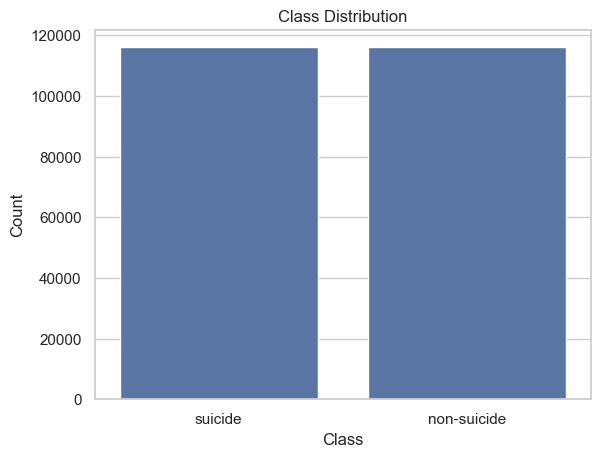

In [5]:
# Class distribution analysis
print(df1["class"].value_counts())
sns.countplot(data=df1, x="class")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### 4. Text Analysis

In [6]:
# Calculate text length (number of words) for each entry
df1["text_length"] = df1["text"].apply(lambda x: len(str(x).split()))
df1["text_length"].describe()

count    232074.000000
mean        131.925235
std         217.476787
min           1.000000
25%          26.000000
50%          60.000000
75%         155.000000
max        9684.000000
Name: text_length, dtype: float64

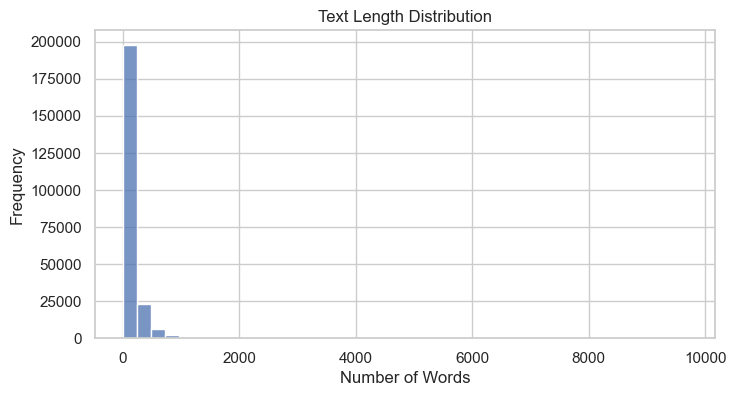

In [7]:
# Histogram of text lengths (number of words)
plt.figure(figsize=(8, 4))
sns.histplot(data=df1, x="text_length", bins=40)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [8]:
# Average text length by class
df1.groupby("class")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
non-suicide,116037.0,61.188302,139.292553,2.0,19.0,31.0,60.0,8220.0
suicide,116037.0,202.662168,255.309193,1.0,60.0,127.0,251.0,9684.0


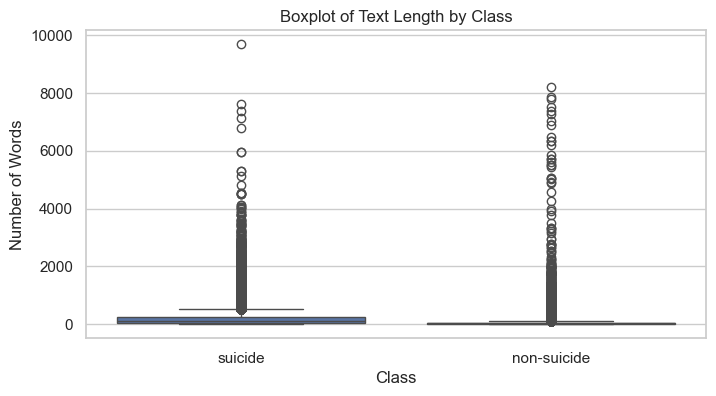

In [9]:
# Boxplot of text length by class
plt.figure(figsize=(8, 4))
sns.boxplot(data=df1, x="class", y="text_length")
plt.title("Boxplot of Text Length by Class")
plt.xlabel("Class")
plt.ylabel("Number of Words")
plt.show()

### 5. Most Frequent Terms

In [10]:
# List the 20 most common words (excluding stopwords)
all_words_ds1 = " ".join(df1["text"].astype(str)).lower().split()
stop_words_ds1 = set(stopwords.words("english"))
all_words_no_stopwords_ds1 = [word for word in all_words_ds1 if word not in stop_words_ds1]
Counter(all_words_no_stopwords_ds1).most_common(20)

[('like', 174564),
 ('want', 145681),
 ('know', 120935),
 ('feel', 119211),
 ('get', 109497),
 ('even', 89801),
 ('i’m', 87004),
 ('would', 83405),
 ('people', 80797),
 ('really', 80359),
 ('one', 80272),
 ('life', 78757),
 ('think', 68412),
 ('me.', 66254),
 ('never', 66129),
 ('going', 64679),
 ("can't", 62362),
 ('time', 62342),
 ('go', 60408),
 ('filler', 53565)]

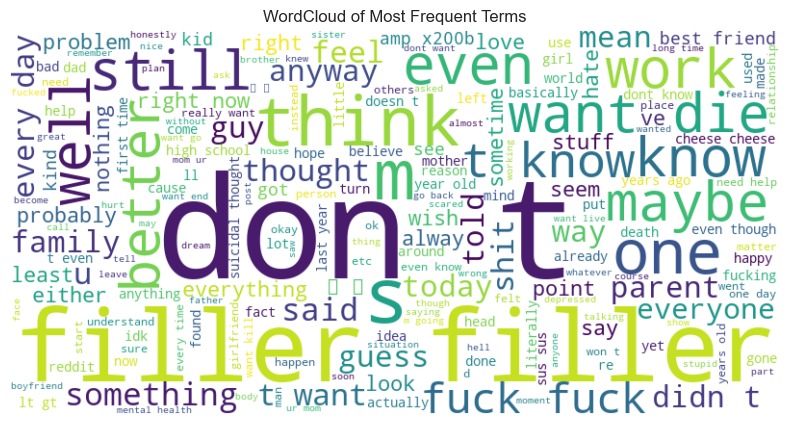

In [11]:
# Visualize the most frequent terms as a word cloud
plt.figure(figsize=(10, 5))
wc_ds1 = WordCloud(width=800, height=400, background_color="white").generate(
    " ".join(all_words_no_stopwords_ds1)
)
plt.imshow(wc_ds1, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Most Frequent Terms")
plt.show()

### 6. Noise and Duplicates Analysis

In [12]:
# Check for duplicate texts
duplicated_ds1 = df1.duplicated(subset=["text"])
print(f"Number of duplicate texts: {duplicated_ds1.sum()}")

Number of duplicate texts: 0


In [13]:
# Show examples of short or empty texts (3 words or less)
df1[df1["text_length"] <= 3][["text", "class"]].head(10)

,text,class
168,lmaolmabsjdbbsjxbwnxhhdjsshdcmwbdjjf jrhdsndhd...,non-suicide
664,adopt mepls,suicide
1757,📱dOnT📱oPeN📱tHe📱fReE📱iPhOnE📱lInK📱iT’s📱a📱vIrUs📱t...,non-suicide
1768,Just OD'dBye.,suicide
3147,Final strawDoing it,suicide
4894,Heeeeeeeeeeelllllllllllllllllooooooooooooooo H...,non-suicide
5047,whhduduehdhttps://wad.ojooo.com/register.php?r...,suicide
5414,ask awayyy https://imgur.com/gallery/FkhMMkU,non-suicide
6147,Backup account \n\n\n\n#WINK,non-suicide
7076,Fuck it.TL;DW,suicide


In [14]:
# Count the number of texts with 3 words or less
num_short_texts_ds1 = df1[df1["text_length"] <= 3].shape[0]
print(f"Number of texts with 3 words or less: {num_short_texts_ds1}")

Number of texts with 3 words or less: 452


In [15]:
# Count the number of short texts by class
short_texts_per_class_ds1 = df1[df1["text_length"] <= 3]["class"].value_counts()
print("Occurrences of each class among short texts:")
print(short_texts_per_class_ds1)

Occurrences of each class among short texts:
class
non-suicide    227
suicide        225
Name: count, dtype: int64


In [16]:
# Check for texts that are only spaces or null
df1[df1["text"].astype(str).str.strip() == ""][["text", "class"]].head()

,text,class


### 7. Final Remarks


- The dataset contains texts of different lengths, with a predominance of short texts, but also examples of longer texts.
- It is observed that texts classified as "suicide" tend to be longer than "non-suicide" texts.
- The class distribution is balanced, which is positive for training classification models.
- No duplicate texts were identified, indicating good quality in this aspect.
- Examples of very short texts (with 3 words or less) were found, which should be handled during preprocessing to avoid noise in modeling.
- The most frequent words are consistent with the mental health context, suggesting that the dataset is relevant to the project's objective.

## Sentiment Analysis for Mental Health Dataset

### 1. Data Loading

In [17]:
# Load Sentiment Analysis for Mental Health dataset
df2 = pd.read_csv("../data/raw/sentiment-analysis-for-mental-health/raw.csv")
# Show the first 10 rows for a quick overview
df2.head(10)

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
5,5,"every break, you must be nervous, like somethi...",Anxiety
6,6,"I feel scared, anxious, what can I do? And may...",Anxiety
7,7,Have you ever felt nervous but didn't know why?,Anxiety
8,8,"I haven't slept well for 2 days, it's like I'm...",Anxiety
9,9,"I'm really worried, I want to cry.",Anxiety


### 2. General Information

In [18]:
# Show structure and types of columns
df2.info()
# Show descriptive statistics for all columns
df2.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


,Unnamed: 0,statement,status
count,53043.000000,52681,53043
unique,NaN,51073,7
top,NaN,what do you mean?,Normal
freq,NaN,22,16351
mean,26521.000000,NaN,NaN
std,15312.339501,NaN,NaN
min,0.000000,NaN,NaN
25%,13260.500000,NaN,NaN
50%,26521.000000,NaN,NaN
75%,39781.500000,NaN,NaN


In [19]:
# Check for missing values in each column
df2.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

### 3. Class Analysis

status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


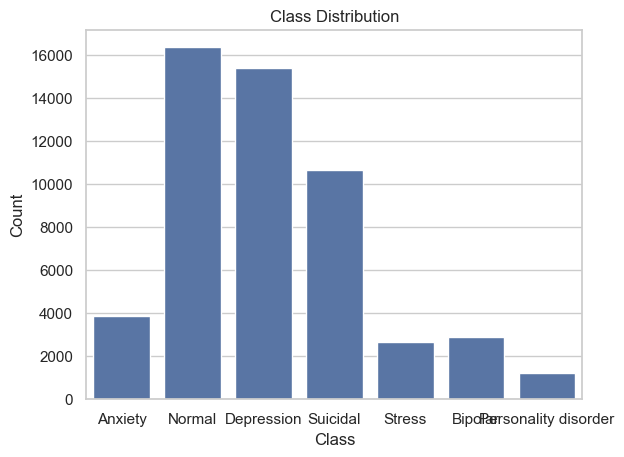

In [20]:
# Class distribution analysis
print(df2["status"].value_counts())
sns.countplot(data=df2, x="status")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### 4. Text Analysis

In [21]:
# Calculate text length (number of words) for each entry
df2["text_length"] = df2["statement"].apply(lambda x: len(str(x).split()))
df2["text_length"].describe()

count    53043.000000
mean       112.393285
std        163.436684
min          1.000000
25%         15.000000
50%         61.000000
75%        147.500000
max       6300.000000
Name: text_length, dtype: float64

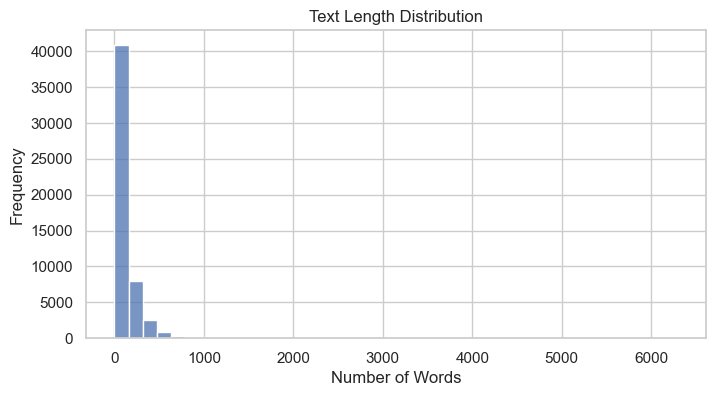

In [22]:
# Histogram of text lengths (number of words)
plt.figure(figsize=(8, 4))
sns.histplot(data=df2, x="text_length", bins=40)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [23]:
# Average text length by class
df2.groupby("status")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
Anxiety,3888.0,142.110340,152.501486,1.0,39.0,101.0,191.0,1592.0
Bipolar,2877.0,170.110532,176.338966,1.0,69.0,125.0,216.0,4804.0
Depression,15404.0,168.021488,188.233087,1.0,54.0,113.0,215.0,4239.0
Normal,16351.0,17.238334,22.766320,1.0,5.0,10.0,18.0,255.0
Personality disorder,1201.0,160.932556,217.015114,1.0,45.0,117.0,220.0,5419.0
Stress,2669.0,111.095541,106.082841,1.0,62.0,85.0,125.0,1606.0
Suicidal,10653.0,146.426640,186.959616,1.0,42.0,92.0,186.0,6300.0


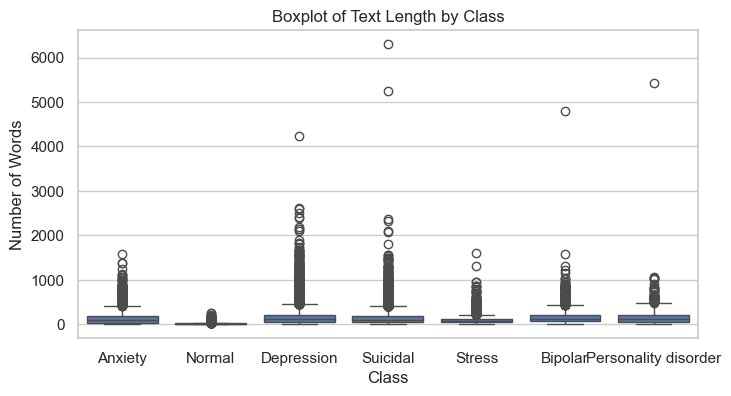

In [24]:
# Boxplot of text length by class
plt.figure(figsize=(8, 4))
sns.boxplot(data=df2, x="status", y="text_length")
plt.title("Boxplot of Text Length by Class")
plt.xlabel("Class")
plt.ylabel("Number of Words")
plt.show()

### 5. Most Frequent Terms

In [25]:
# List the 20 most common words (excluding stopwords)
all_words_ds2 = " ".join(df2["statement"].astype(str)).lower().split()
stop_words_ds2 = set(stopwords.words("english"))
all_words_no_stopwords_ds2 = [word for word in all_words_ds2 if word not in stop_words_ds2]
Counter(all_words_no_stopwords_ds2).most_common(20)

[('like', 37128),
 ('feel', 31010),
 ('want', 26851),
 ('know', 22052),
 ('get', 21507),
 ('even', 18505),
 ('would', 16686),
 ('really', 15916),
 ('life', 15790),
 ('cannot', 14968),
 ('people', 14523),
 ('time', 13741),
 ('one', 13512),
 ('going', 13424),
 ('think', 12477),
 ('never', 11685),
 ('go', 11490),
 ('much', 10179),
 ('could', 9599),
 ('me.', 9460)]

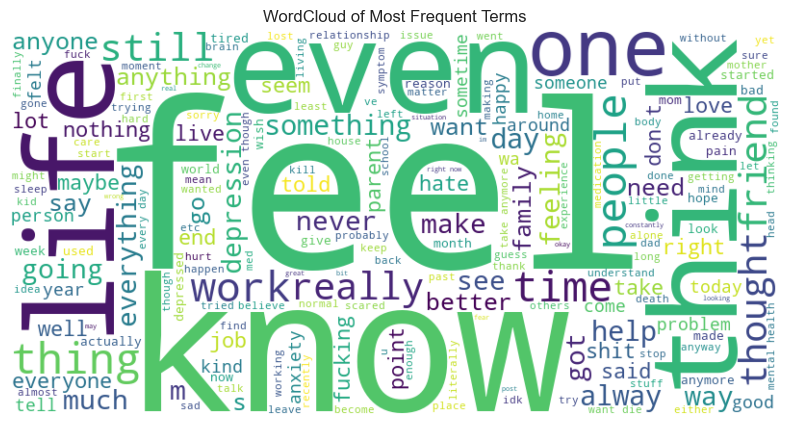

In [26]:
# Visualize the most frequent terms as a word cloud
plt.figure(figsize=(10, 5))
wc_ds2 = WordCloud(width=800, height=400, background_color="white").generate(
    " ".join(all_words_no_stopwords_ds2)
)
plt.imshow(wc_ds2, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Most Frequent Terms")
plt.show()

### 6. Noise and Duplicates Analysis

In [27]:
# Check for duplicate texts
duplicated_ds2 = df2.duplicated(subset=["statement"])
print(f"Number of duplicate texts: {duplicated_ds2.sum()}")

Number of duplicate texts: 1969


In [28]:
# Show examples of short or empty texts (3 words or less)
df2[df2["text_length"] <= 3][["statement", "status"]].head(10)

,statement,status
0,oh my gosh,Anxiety
32,Terooosss nervous huuuu,Anxiety
53,Restless.. and.. restless..,Anxiety
60,Very restless bgsd,Anxiety
67,nervous restless peramoy,Anxiety
70,It feels uneasy.,Anxiety
78,Restless and agitated.,Anxiety
88,Anxious,Anxiety
119,controlling excessive anxiety,Anxiety
150,Keep restless astagfirullah,Anxiety


In [29]:
# Count the number of texts with 3 words or less
num_short_texts_ds2 = df2[df2["text_length"] <= 3].shape[0]
print(f"Number of texts with 3 words or less: {num_short_texts_ds2}")

Number of texts with 3 words or less: 2184


In [30]:
# Count the number of short texts by class
short_texts_per_class_ds2 = df2[df2["text_length"] <= 3]["status"].value_counts()
print("Occurrences of each class among short texts:")
print(short_texts_per_class_ds2)

Occurrences of each class among short texts:
status
Normal                  1706
Personality disorder     124
Bipolar                  100
Anxiety                   95
Stress                    87
Depression                55
Suicidal                  17
Name: count, dtype: int64


In [31]:
# Check for texts that are only spaces or null
df2[df2["statement"].astype(str).str.strip() == ""][["statement", "status"]].head()

,statement,status


### 7. Final Remarks


- The dataset contains texts of different lengths, with the presence of short texts, especially in the "Normal" class.
- Texts classified as "Normal" tend to be shorter than those of other classes.
- The class distribution is unbalanced, with the classes "Normal", "Depression", and "Suicidal" concentrating most samples, while other classes have far fewer occurrences.
- Duplicate texts were identified, reinforcing the need to remove these duplicates during preprocessing.
- Examples of very short texts (with 3 words or less) were also found, which should be handled to avoid noise in modeling.
- The most frequent words are consistent with the mental health context, indicating that the dataset is relevant to the project's objectives.

## Sentimental Analysis for Tweets Dataset

### 1. Data Loading

In [32]:
# Load Sentimental Analysis for Tweets dataset
df3 = pd.read_csv("../data/raw/sentimental-analysis-for-tweets/raw.csv")
# Show the first 10 rows for a quick overview
df3.head(10)

,Index,message to examine,label (depression result)
0,106,just had a real good moment. i missssssssss hi...,0
1,217,is reading manga http://plurk.com/p/mzp1e,0
2,220,@comeagainjen http://twitpic.com/2y2lx - http:...,0
3,288,@lapcat Need to send 'em to my accountant tomo...,0
4,540,ADD ME ON MYSPACE!!! myspace.com/LookThunder,0
5,624,so sleepy. good times tonight though,0
6,701,"@SilkCharm re: #nbn as someone already said, d...",0
7,808,23 or 24ï¿½C possible today. Nice,0
8,1193,nite twitterville workout in the am -ciao,0
9,1324,"@daNanner Night, darlin'! Sweet dreams to you",0


### 2. General Information

In [33]:
# Show structure and types of columns
df3.info()
# Show descriptive statistics for all columns
df3.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10314 entries, 0 to 10313
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      10314 non-null  int64 
 1   message to examine         10314 non-null  object
 2   label (depression result)  10314 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 241.9+ KB


,Index,message to examine,label (depression result)
count,10314.000000,10314,10314.000000
unique,NaN,10282,NaN
top,NaN,"Mom's depression tied to kids' emotional, inte...",NaN
freq,NaN,11,NaN
mean,491253.470525,NaN,0.224355
std,261688.134407,NaN,0.417177
min,106.000000,NaN,0.000000
25%,263019.250000,NaN,0.000000
50%,514988.000000,NaN,0.000000
75%,773521.500000,NaN,0.000000


In [34]:
# Check for missing values in each column
df3.isnull().sum()

Index                        0
message to examine           0
label (depression result)    0
dtype: int64

### 3. Class Analysis

label (depression result)
0    8000
1    2314
Name: count, dtype: int64


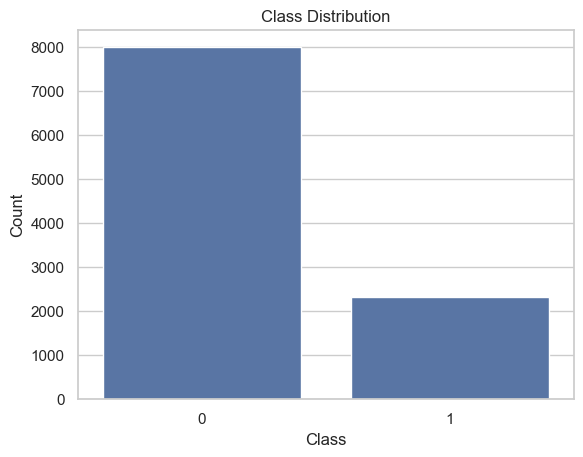

In [35]:
# Class distribution analysis
print(df3["label (depression result)"].value_counts())
sns.countplot(data=df3, x="label (depression result)")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### 4. Text Analysis

In [36]:
# Calculate text length (number of words) for each entry
df3["text_length"] = df3["message to examine"].apply(lambda x: len(str(x).split()))
df3["text_length"].describe()

count    10314.000000
mean        15.068548
std         10.131983
min          1.000000
25%          8.000000
50%         13.000000
75%         20.000000
max         92.000000
Name: text_length, dtype: float64

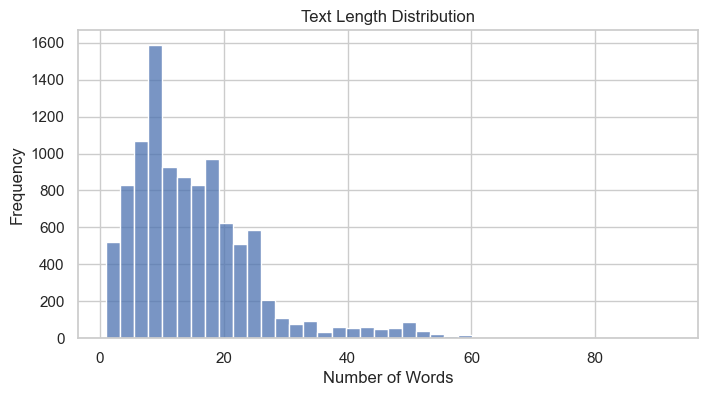

In [37]:
# Histogram of text lengths (number of words)
plt.figure(figsize=(8, 4))
sns.histplot(data=df3, x="text_length", bins=40)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [38]:
# Average text length by class
df3.groupby("label (depression result)")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label (depression result),,,,,,,,
0,8000.0,12.736250,6.788074,1.0,7.0,12.0,18.0,32.0
1,2314.0,23.131806,14.646148,1.0,11.0,19.0,33.0,92.0


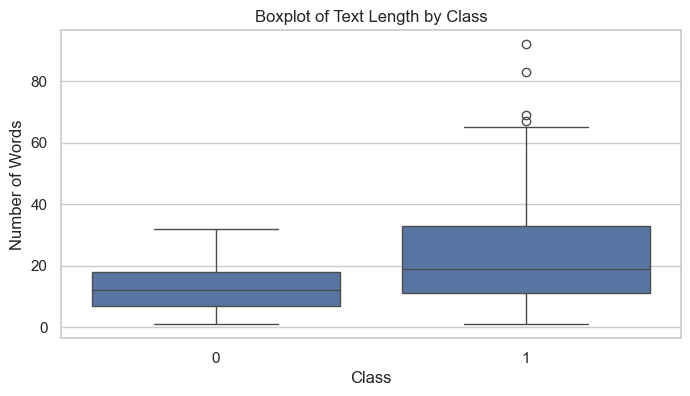

In [39]:
# Boxplot of text length by class
plt.figure(figsize=(8, 4))
sns.boxplot(data=df3, x="label (depression result)", y="text_length")
plt.title("Boxplot of Text Length by Class")
plt.xlabel("Class")
plt.ylabel("Number of Words")
plt.show()

### 5. Most Frequent Terms

In [40]:
# List the 20 most common words (excluding stopwords)
all_words_ds3 = " ".join(df3["message to examine"].astype(str)).lower().split()
stop_words_ds3 = set(stopwords.words("english"))
all_words_no_stopwords_ds3 = [word for word in all_words_ds3 if word not in stop_words_ds3]
Counter(all_words_no_stopwords_ds3).most_common(20)

[('depression', 1576),
 ('good', 603),
 ('-', 536),
 ('like', 530),
 ('love', 516),
 ('get', 479),
 ('day', 409),
 ('â\x80¦', 372),
 ('going', 355),
 ('go', 341),
 ('u', 335),
 ('know', 333),
 ('got', 328),
 ('time', 311),
 ('new', 310),
 ('see', 308),
 ('one', 302),
 ('lol', 281),
 ('great', 275),
 ('thanks', 274)]

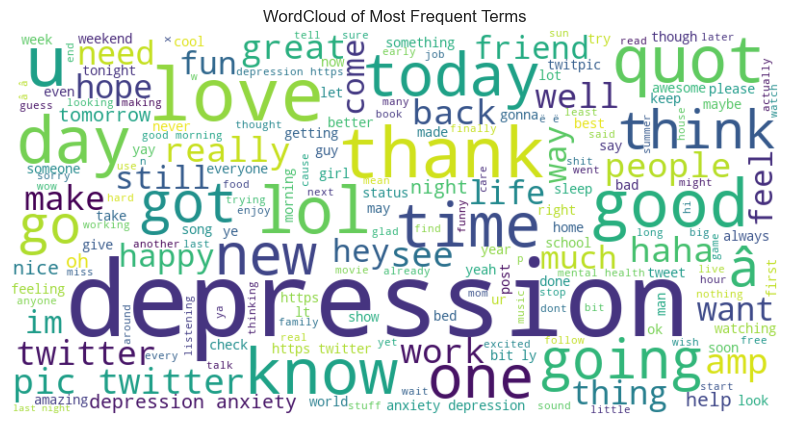

In [41]:
# Visualize the most frequent terms as a word cloud
plt.figure(figsize=(10, 5))
wc_ds3 = WordCloud(width=800, height=400, background_color="white").generate(
    " ".join(all_words_no_stopwords_ds3)
)
plt.imshow(wc_ds3, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Most Frequent Terms")
plt.show()

### 6. Noise and Duplicates Analysis

In [42]:
# Check for duplicate texts
duplicated_ds3 = df3.duplicated(subset=["message to examine"])
print(f"Number of duplicate texts: {duplicated_ds3.sum()}")

Number of duplicate texts: 32


In [43]:
# Show examples of short or empty texts (3 words or less)
df3[df3["text_length"] <= 3][["message to examine", "label (depression result)"]].head(10)

,message to examine,label (depression result)
10,Good morning everybody!,0
43,@TayJasper alrite thanxx,0
47,@tcouto Cool stuff!,0
69,@RLN49 Too funny!,0
73,Is in Athens,0
98,i'm listening MUSIC,0
143,@azcameron serious business,0
156,@RealWorldMom,0
159,is going outside,0
161,Is with alyssa,0


In [44]:
# Count the number of texts with 3 words or less
num_short_texts_ds3 = df3[df3["text_length"] <= 3].shape[0]
print(f"Number of texts with 3 words or less: {num_short_texts_ds3}")

Number of texts with 3 words or less: 520


In [45]:
# Count the number of short texts by class
short_texts_per_class_ds3 = df3[df3["text_length"] <= 3]["label (depression result)"].value_counts()
print("Occurrences of each class among short texts:")
print(short_texts_per_class_ds3)

Occurrences of each class among short texts:
label (depression result)
0    473
1     47
Name: count, dtype: int64


In [46]:
# Check for texts that are only spaces or null
df3[df3["message to examine"].astype(str).str.strip() == ""][["message to examine", "label (depression result)"]].head()

,message to examine,label (depression result)


### 7. Final Remarks


- The dataset contains texts of different lengths, with most being short texts (on average, ~13 words for the non-depression class and ~23 words for the depression class).
- Texts classified as depressive tend to be longer than non-depressive texts, indicating a possible difference in expression between the groups.
- The class distribution is unbalanced, with a significantly higher number of non-depressive texts (5686 more).
- Duplicate texts were identified, reinforcing the need to remove these duplicates to avoid bias in training.
- Examples of very short texts (with 3 words or less) were also found, which should be handled or removed to avoid noise in modeling.
- The most frequent words are consistent with the mental health context, suggesting that the dataset is relevant to the project's objective.

## Mental Health Corpus Dataset

### 1. Data Loading

In [47]:
# Load Mental Health Corpus dataset
df4 = pd.read_csv("../data/raw/mental-health-corpus/raw.csv")
# Show the first 10 rows for a quick overview
df4.head(10)

,text,label
0,dear american teens question dutch person hear...,0
1,nothing look forward lifei dont many reasons k...,1
2,music recommendations im looking expand playli...,0
3,im done trying feel betterthe reason im still ...,1
4,worried year old girl subject domestic physic...,1
5,hey rredflag sure right place post this goes ...,1
6,feel like someone needs hear tonight feeling r...,0
7,deserve liveif died right noone would carei re...,1
8,feels good ive set dateim killing friday nice ...,1
9,live guiltok made stupid random choice its ge...,1


### 2. General Information

In [48]:
# Show structure and types of columns
df4.info()
# Show descriptive statistics for all columns
df4.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27977 entries, 0 to 27976
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    27977 non-null  object
 1   label   27977 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 437.3+ KB


,text,label
count,27977,27977.000000
unique,27972,NaN
top,real suppleroot hours up day far,NaN
freq,3,NaN
mean,NaN,0.494621
std,NaN,0.499980
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,0.000000
75%,NaN,1.000000


In [49]:
# Check for missing values in each column
df4.isnull().sum()

text     0
label    0
dtype: int64

### 3. Class Analysis

label
0    14139
1    13838
Name: count, dtype: int64


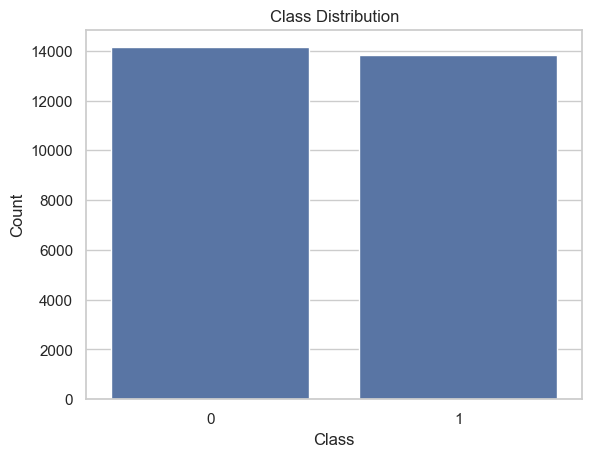

In [50]:
# Class distribution analysis
print(df4["label"].value_counts())
sns.countplot(data=df4, x="label")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### 4. Text Analysis

In [51]:
# Calculate text length (number of words) for each entry
df4["text_length"] = df4["text"].apply(lambda x: len(str(x).split()))
df4["text_length"].describe()

count    27977.000000
mean        71.759410
std        103.802417
min          0.000000
25%         16.000000
50%         38.000000
75%         87.000000
max       2676.000000
Name: text_length, dtype: float64

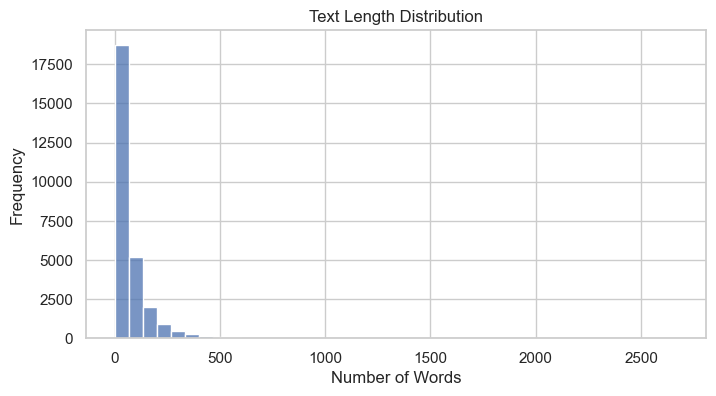

In [52]:
# Histogram of text lengths (number of words)
plt.figure(figsize=(8, 4))
sns.histplot(data=df4, x="text_length", bins=40)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [53]:
# Average text length by class
df4.groupby("label")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,14139.0,47.387580,71.064117,0.0,11.0,21.0,55.0,1462.0
1,13838.0,96.661367,124.088617,0.0,29.0,60.0,119.0,2676.0


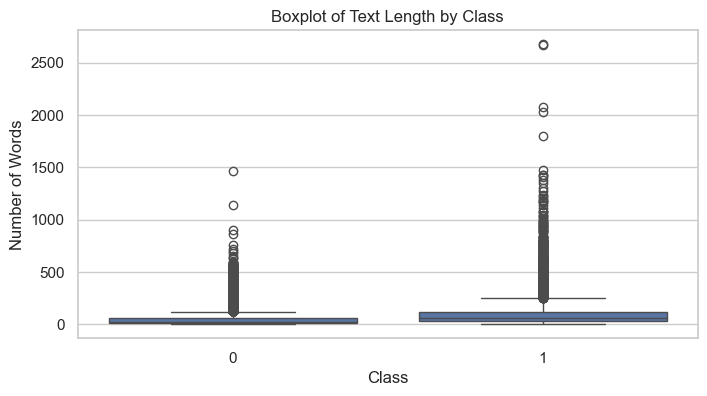

In [54]:
# Boxplot of text length by class
plt.figure(figsize=(8, 4))
sns.boxplot(data=df4, x="label", y="text_length")
plt.title("Boxplot of Text Length by Class")
plt.xlabel("Class")
plt.ylabel("Number of Words")
plt.show()

### 5. Most Frequent Terms

In [55]:
# List the 20 most common words (excluding stopwords)
all_words_ds4 = " ".join(df4["text"].astype(str)).lower().split()
stop_words_ds4 = set(stopwords.words("english"))
all_words_no_stopwords_ds4 = [word for word in all_words_ds4 if word not in stop_words_ds4]
Counter(all_words_no_stopwords_ds4).most_common(20)

[('im', 34720),
 ('like', 22300),
 ('want', 17299),
 ('know', 15475),
 ('feel', 14508),
 ('life', 14386),
 ('get', 13094),
 ('one', 12405),
 ('even', 11497),
 ('ive', 11287),
 ('people', 11249),
 ('would', 11001),
 ('time', 10829),
 ('cant', 10446),
 ('really', 10187),
 ('think', 8615),
 ('never', 8031),
 ('going', 7959),
 ('go', 7898),
 ('dont', 7829)]

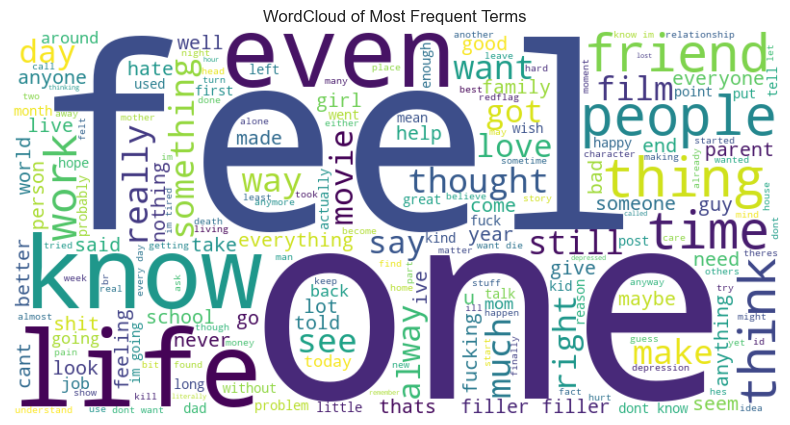

In [56]:
# Visualize the most frequent terms as a word cloud
plt.figure(figsize=(10, 5))
wc_ds4 = WordCloud(width=800, height=400, background_color="white").generate(
    " ".join(all_words_no_stopwords_ds4)
)
plt.imshow(wc_ds4, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Most Frequent Terms")
plt.show()

### 6. Noise and Duplicates Analysis

In [57]:
# Check for duplicate texts
duplicated_ds4 = df4.duplicated(subset=["text"])
print(f"Number of duplicate texts: {duplicated_ds4.sum()}")

Number of duplicate texts: 5


In [58]:
# Show examples of short or empty texts (3 words or less)
df4[df4["text_length"] <= 3][["text", "label"]].head(10)

,text,label
38,eat decide,0
305,kicked downccc,1
314,talk favorite theories,0
538,help mehelp pelase,1
566,good morning yall,0
630,listening megalovania,0
654,sleep,0
674,turned guys bye,0
743,rick roll httpswwwyoutubecomwatchvnmlkiashttps...,0
873,im going tomorrowbye,1


In [59]:
# Count the number of texts with 3 words or less
num_short_texts_ds4 = df4[df4["text_length"] <= 3].shape[0]
print(f"Number of texts with 3 words or less: {num_short_texts_ds4}")

Number of texts with 3 words or less: 229


In [60]:
# Count the number of short texts by class
short_texts_per_class_ds4 = df4[df4["text_length"] <= 3]["label"].value_counts()
print("Occurrences of each class among short texts:")
print(short_texts_per_class_ds4)

Occurrences of each class among short texts:
label
0    144
1     85
Name: count, dtype: int64


In [61]:
# Check for texts that are only spaces or null
df4[df4["text"].astype(str).str.strip() == ""][["text", "label"]].head()

,text,label
6579,,0
13183,,1


### 7. Final Remarks


- The dataset contains texts of different lengths, with a predominance of short texts, but also more extensive examples. The average length is 71 characters, with the toxic comments class having longer texts on average.
- Texts classified as toxic tend to be longer than non-toxic texts, indicating a possible difference in expression patterns between the classes.
- The class distribution is slightly unbalanced, which may require attention during model training to avoid bias.
- Some duplicate texts were identified, reinforcing the importance of removing them during preprocessing to ensure data quality.
- Examples of very short texts (with 3 words or less) were also found, which should be removed or handled to avoid noise in modeling.
- The most frequent words are consistent with the mental health context, suggesting that the dataset is relevant to the project's objective.

## Next Steps


- Implement preprocessing pipeline (cleaning, normalization, noise removal).